In [6]:
import cv2
import numpy as np
from skimage.restoration import denoise_bilateral

img1 = cv2.imread("img1.png")
img2 = cv2.imread("img2.png")

if img1 is None or img2 is None:
    raise ValueError("Check image paths")

h = min(img1.shape[0], img2.shape[0])
w = min(img1.shape[1], img2.shape[1])
img1 = cv2.resize(img1, (w, h))
img2 = cv2.resize(img2, (w, h))

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

mask = np.zeros((h, w), dtype=np.uint8)
mask[:, : w // 2] = 255
mask[:, w // 2 :] = 0

cv2.imwrite("mask_init.png", mask)

center = (w // 2, h // 2)

poisson_blend = cv2.seamlessClone(
    src=img1,
    dst=img2,
    mask=mask,
    p=center,
    flags=cv2.NORMAL_CLONE
)

cv2.imwrite("poisson_blend.png", poisson_blend)

bilateral = cv2.bilateralFilter(
    poisson_blend, d=9, sigmaColor=25, sigmaSpace=25
)
cv2.imwrite("bilateral_refined.png", bilateral)

blend_float = cv2.cvtColor(poisson_blend, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

gray = cv2.cvtColor(poisson_blend, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

refined = np.zeros_like(blend_float)
for c in range(3):
    refined[..., c] = denoise_bilateral(
        blend_float[..., c],
        sigma_color=0.1,
        sigma_spatial=5,
        channel_axis=None
    )

refined_bgr = (refined * 255.0).clip(0, 255).astype(np.uint8)
refined_bgr = cv2.cvtColor(refined_bgr, cv2.COLOR_RGB2BGR)
cv2.imwrite("guided_like_refined.png", refined_bgr)

print("Saved: mask_init.png, poisson_blend.png, bilateral_refined.png, guided_like_refined.png")


Saved: mask_init.png, poisson_blend.png, bilateral_refined.png, guided_like_refined.png


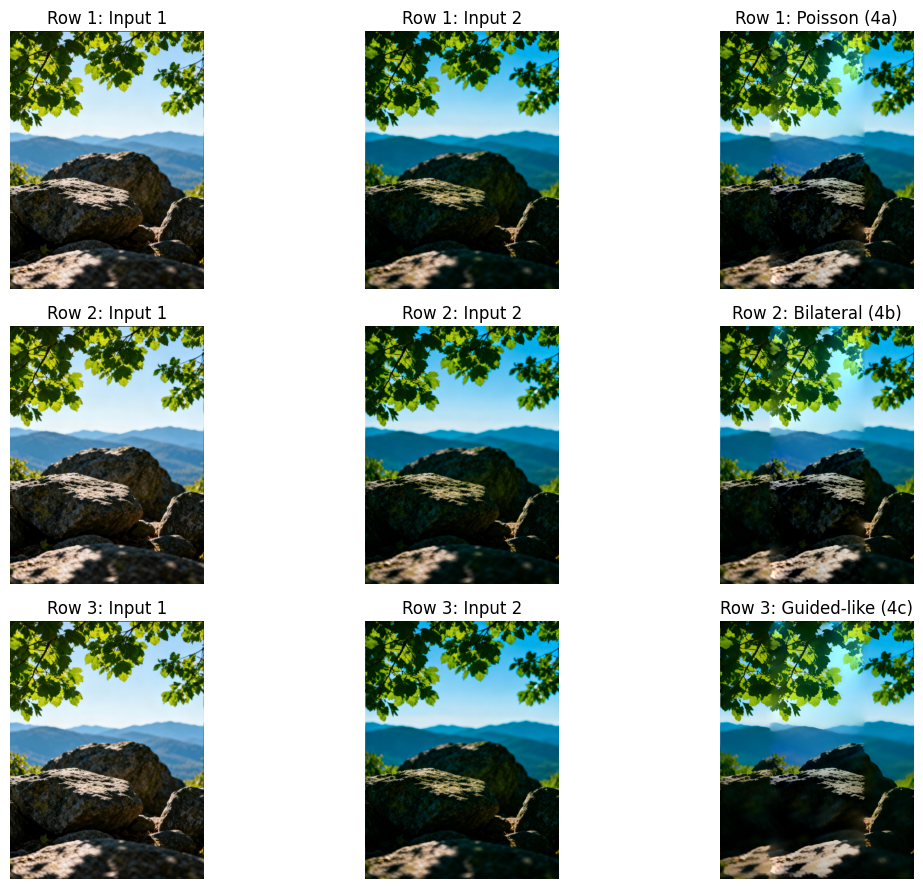

In [7]:
import matplotlib.pyplot as plt

img1_plot = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_plot = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
poisson_plot = cv2.cvtColor(poisson_blend, cv2.COLOR_BGR2RGB)
bilateral_plot = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB)
guided_plot = cv2.cvtColor(refined_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 9))

plt.subplot(3, 3, 1)
plt.imshow(img1_plot)
plt.title("Row 1: Input 1")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(img2_plot)
plt.title("Row 1: Input 2")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(poisson_plot)
plt.title("Row 1: Poisson (4a)")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(img1_plot)
plt.title("Row 2: Input 1")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(img2_plot)
plt.title("Row 2: Input 2")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(bilateral_plot)
plt.title("Row 2: Bilateral (4b)")
plt.axis("off")

plt.subplot(3, 3, 7)
plt.imshow(img1_plot)
plt.title("Row 3: Input 1")
plt.axis("off")

plt.subplot(3, 3, 8)
plt.imshow(img2_plot)
plt.title("Row 3: Input 2")
plt.axis("off")

plt.subplot(3, 3, 9)
plt.imshow(guided_plot)
plt.title("Row 3: Guided-like (4c)")
plt.axis("off")

plt.tight_layout()
plt.show()
